In [1]:
# Упражнение: N-gram модели на ниво думи
# Корпус: Иван Вазов — "Драски и шарки"

In [2]:
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (12, 4)

In [4]:
# Зареждаме текста
with open("../data/ivan_vazov.txt", "r") as f:
    text = f.read()

print(f"Размер: {len(text):,} символа")
print(text[:500])

Размер: 3,990,245 символа
﻿	Иван Вазов
	Драски и шарки

	I част
	Украсил столицата

	Всеки, който го познаваше преди две години, помни как беше съвсем други човек господин Бучински: лек, приятен и весел, винаги в добро разположение на духа, което имаше заразително действие въз другите. Той търсеше тогава обществото, което също го търсеше; интересуваха го всичките новини градски и всичките общи въпроси, и най-добрите мезелици, и политиката, и съдбата на Бисмарка, и даже литературата…
	Сега вече господин Бучински е съвсем 


In [5]:
import random

In [6]:
chunks = text.split('* * *')

In [7]:
random.shuffle(chunks)

In [8]:
text = '* * *'.join(chunks)

In [9]:
# Разбиване на текста и изчистване на думите
import re

def split_into_words(text: str) -> list[str]:
   return re.findall(r"[\w]+(?:'[\w]+)*", text.lower(), flags=re.UNICODE)

In [10]:
# Разделяме на думи (split по whitespace)
words = split_into_words(text)

print(f"Общо думи: {len(words):,}")
print(f"Уникални думи: {len(set(words)):,}")

Общо думи: 657,835
Уникални думи: 65,783


In [11]:
# === UNIGRAM МОДЕЛ ===
# Честота на отделните думи
unigram_counts = Counter(words)

print("Топ 30 най-чести думи:")
for word, count in unigram_counts.most_common(30):
    print(f"  {word:15s} {count:6,d}")

Топ 30 най-чести думи:
  и               26,655
  на              20,315
  се              15,886
  да              14,903
  в               11,965
  от               9,143
  с                8,800
  не               8,046
  си               8,025
  за               6,486
  е                6,206
  той              6,196
  му               5,369
  по               5,041
  че               4,073
  като             3,652
  го               3,573
  но               3,394
  беше             3,218
  аз               2,996
  ще               2,957
  това             2,636
  ти               2,527
  един             2,443
  ми               2,368
  тя               2,251
  а                2,247
  една             1,829
  ли               1,726
  ни               1,675


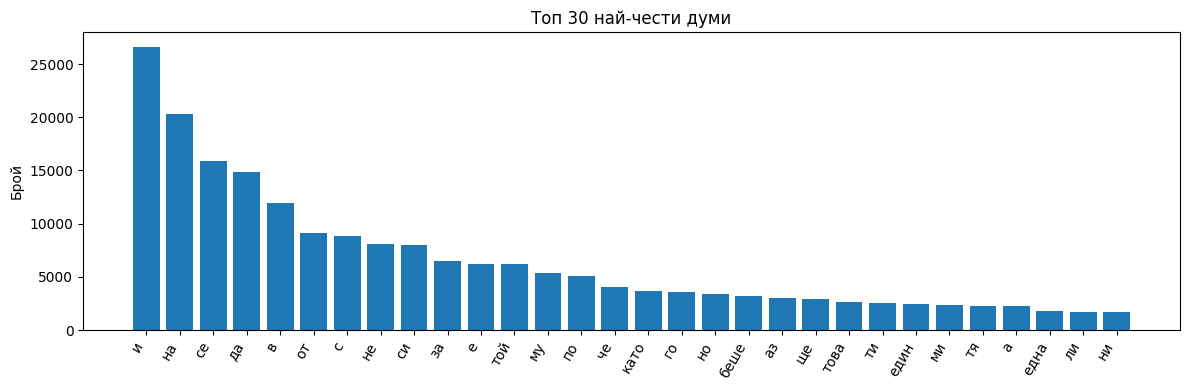

In [12]:
# Визуализация: топ 30 думи
top_words = unigram_counts.most_common(30)
plt.bar([w for w, _ in top_words], [c for _, c in top_words])
plt.title("Топ 30 най-чести думи")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Брой")
plt.tight_layout()
plt.show()

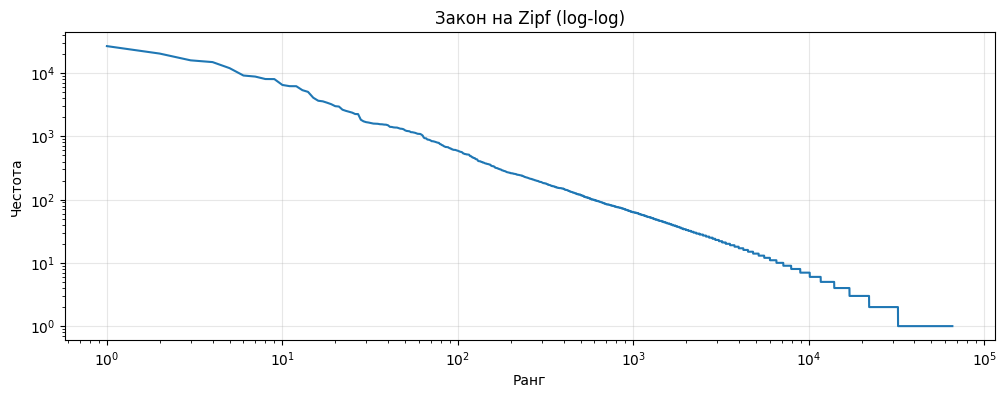

In [13]:
# Закон на Zipf: честотата е обратно пропорционална на ранга
ranks = range(1, len(unigram_counts) + 1)
freqs = [c for _, c in unigram_counts.most_common()]

plt.loglog(list(ranks), freqs)
plt.title("Закон на Zipf (log-log)")
plt.xlabel("Ранг")
plt.ylabel("Честота")
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# === BIGRAM МОДЕЛ ===
# Двойки последователни думи
bigrams = list(zip(words[:-1], words[1:]))
bigram_counts = Counter(bigrams)

print(f"Общо bigram-и: {len(bigrams):,}")
print(f"Уникални bigram-и: {len(bigram_counts):,}")

Общо bigram-и: 657,834
Уникални bigram-и: 405,672


In [ ]:
# Най-чести биграми
print("Топ 30 биграми:")
for (w1, w2), count in bigram_counts.most_common(30):
    print(f"  {w1} : {w2:20s} | {count:5,d}")

Топ 30 bigram-и:
  да : се                   | 1,945
  за : да                   |   957
  и : се                   |   727
  той : се                   |   647
  и : с                    |   607
  да : го                   |   604
  и : да                   |   591
  и : той                  |   549
  си : и                    |   513
  и : на                   |   488
  не : е                    |   469
  да : не                   |   457
  му : се                   |   439
  и : в                    |   432
  да : си                   |   421
  не : се                   |   387
  може : да                   |   347
  да : му                   |   344
  без : да                   |   343
  и : аз                   |   337
  се : не                   |   334
  той : беше                 |   329
  ще : се                   |   324
  да : я                    |   312
  той : не                   |   311
  трябва : да                   |   305
  и : по                   |   292
  да : ги

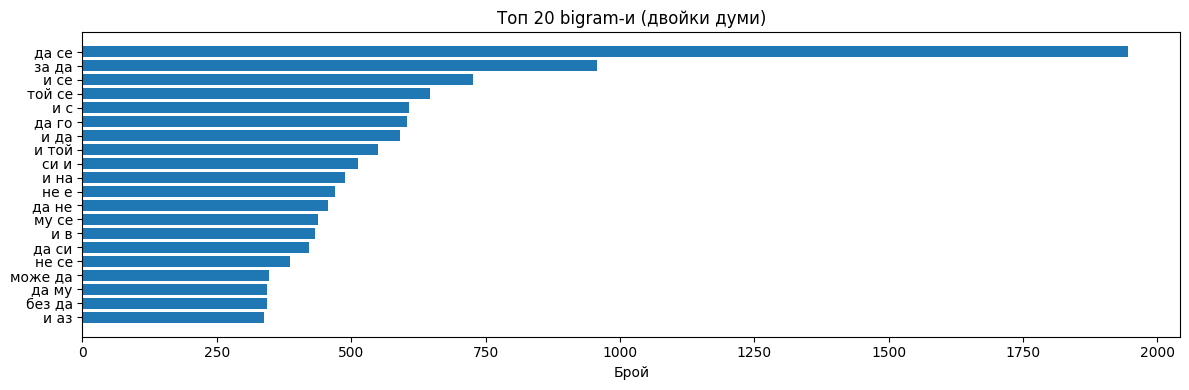

In [ ]:
# Визуализация: топ 20 биграми
top_bigrams = bigram_counts.most_common(20)
labels = [f"{w1} {w2}" for (w1, w2), _ in top_bigrams]
counts = [c for _, c in top_bigrams]

plt.barh(labels[::-1], counts[::-1])
plt.title("Топ 20 bigram-и (двойки думи)")
plt.xlabel("Брой")
plt.tight_layout()
plt.show()

In [17]:
# Преходи: кои думи най-често следват дадена дума?
def top_transitions(word, bigram_counts, n=10):
    transitions = {(w1, w2): c for (w1, w2), c in bigram_counts.items() if w1 == word}
    return Counter(transitions).most_common(n)

for probe in ["на", "и", "не", "да"]:
    print(f'\nСлед "{probe}":')
    for (w1, w2), count in top_transitions(probe, bigram_counts, 8):
        print(f"  → {w2:15s} {count:4d}")


След "на":
  → един             251
  → тая              182
  → тоя              181
  → една             181
  → това             157
  → едно             144
  → тия              119
  → улицата          105

След "и":
  → се               727
  → с                607
  → да               591
  → той              549
  → на               488
  → в                432
  → аз               337
  → по               292

След "не":
  → е                469
  → се               387
  → беше             236
  → може             171
  → съм              134
  → можеше           122
  → бе               106
  → знам             103

След "да":
  → се              1945
  → го               604
  → не               457
  → си               421
  → му               344
  → я                312
  → ги               292
  → бъде             223


In [ ]:
# === TRIGRAM МОДЕЛ ===
# Тройки последователни думи
trigrams = list(zip(words[:-2], words[1:-1], words[2:]))
trigram_counts = Counter(trigrams)

print(f"Общо триграми: {len(trigrams):,}")
print(f"Уникални триграми: {len(trigram_counts):,}")

Общо trigram-и: 657,833
Уникални trigram-и: 610,218


In [ ]:
# Най-чести trigram-и
print("Топ 30 триграми:")
for (w1, w2, w3), count in trigram_counts.most_common(30):
    print(f"  {w1} {w2} {w3:20s} {count:4,d}")

Топ 30 trigram-и:
  за да се                    115
  се обърна към                   105
  не може да                    102
  не можеше да                    102
  и да се                    101
  да се не                     77
  за да не                     73
  в това време                  69
  не мога да                     61
  може да се                     58
  за да го                     57
  трябва да се                     53
  и той се                     50
  в същия миг                    49
  да му се                     48
  в тоя миг                    46
  без да се                     43
  в душата му                     41
  трябваше да се                     41
  да ти кажа                   40
  може би и                      40
  в дъното на                     38
  пред себе си                     37
  можеше да се                     37
  не можа да                     36
  си за да                     36
  няма да се                     35
  за да си       

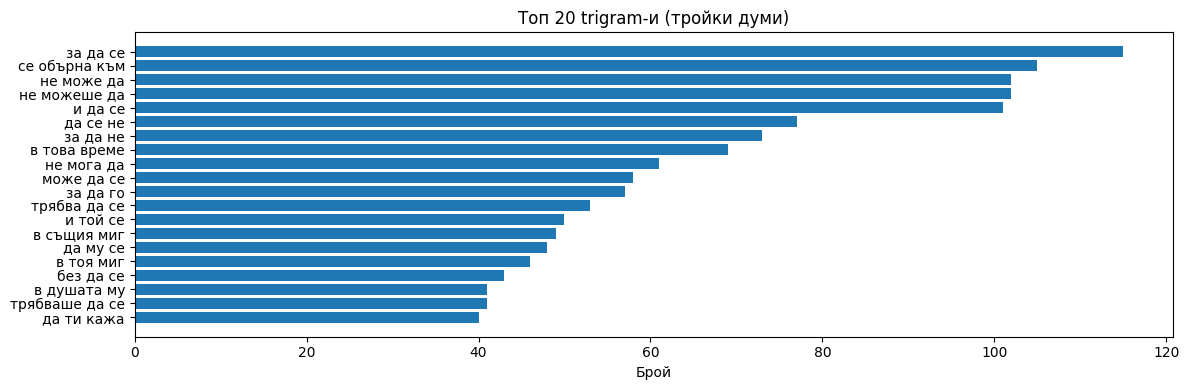

In [20]:
# Визуализация: топ 20 trigram-и
top_trigrams = trigram_counts.most_common(20)
labels = [f"{w1} {w2} {w3}" for (w1, w2, w3), _ in top_trigrams]
counts = [c for _, c in top_trigrams]

plt.barh(labels[::-1], counts[::-1])
plt.title("Топ 20 trigram-и (тройки думи)")
plt.xlabel("Брой")
plt.tight_layout()
plt.show()

In [21]:
# === TRAIN / TEST РАЗДЕЛЯНЕ ===
split_idx = int(len(words) * 0.8)
train_words = words[:split_idx]
test_words = words[split_idx:]

print(f"Train: {len(train_words):,} думи")
print(f"Test:  {len(test_words):,} думи")

Train: 526,268 думи
Test:  131,567 думи


In [22]:
# Bigram-и в train и test
train_bigrams = set(zip(train_words[:-1], train_words[1:]))
test_bigrams = set(zip(test_words[:-1], test_words[1:]))

print(f"Уникални bigram-и в train: {len(train_bigrams):,}")
print(f"Уникални bigram-и в test:  {len(test_bigrams):,}")

Уникални bigram-и в train: 336,105
Уникални bigram-и в test:  96,822


In [23]:
# Bigram-и, които се срещат в test, но НЕ в train
unseen_bigrams = test_bigrams - train_bigrams

print(f"Bigram-и в test, но не в train: {len(unseen_bigrams):,}")
print(f"Процент невидяни: {len(unseen_bigrams) / len(test_bigrams) * 100:.1f}%")
print(f"\nПримери (първите 20):")
for w1, w2 in sorted(unseen_bigrams)[500:550]:
    print(f"  {w1} {w2}")

Bigram-и в test, но не в train: 69,566
Процент невидяни: 71.8%

Примери (първите 20):
  xvii подир
  xvii положението
  xvii чоки
  xviii беше
  xviii извънреден
  xviii кардашев
  xviii новият
  xx противната
  xx танаско
  xx тъмнини
  xxi в
  xxi едно
  xxi яростта
  xxii засада
  xxii кумирът
  xxii при
  xxiii богор
  xxiii брат
  xxiii не
  xxiv нощно
  xxiv поради
  xxiv радоилово
  xxix зловеща
  xxv лудницата
  xxv свиждането
  xxv смилец
  xxvi балдювата
  xxvi бяг
  xxvi митинг
  xxvii една
  xxvii съдбоносният
  xxvii тлъка
  xxviii балдю
  xxviii и
  xxviii отец
  xxx нощно
  xxx подир
  xxxi втора
  xxxi върховното
  xxxii 18
  xxxii с
  xxxiii в
  xxxiii неуловимите
  xxxiv долу
  xxxiv пир
  xxxix пак
  xxxix съдбата
  xxxv the
  xxxv човешки
  xxxvi гръмотевиците


In [24]:
# Trigram-и в train и test
train_trigrams = set(zip(train_words[:-2], train_words[1:-1], train_words[2:]))
test_trigrams = set(zip(test_words[:-2], test_words[1:-1], test_words[2:]))

print(f"Уникални trigram-и в train: {len(train_trigrams):,}")
print(f"Уникални trigram-и в test:  {len(test_trigrams):,}")

Уникални trigram-и в train: 491,986
Уникални trigram-и в test:  126,826


In [25]:
# Trigram-и, които се срещат в test, но НЕ в train
unseen_trigrams = test_trigrams - train_trigrams

print(f"Trigram-и в test, но не в train: {len(unseen_trigrams):,}")
print(f"Процент невидяни: {len(unseen_trigrams) / len(test_trigrams) * 100:.1f}%")
print(f"\nПримери (първите 20):")
for w1, w2, w3 in sorted(unseen_trigrams)[:20]:
    print(f"  {w1} {w2} {w3}")

Trigram-и в test, но не в train: 118,230
Процент невидяни: 93.2%

Примери (първите 20):
  1 радослава бил
  1 септември 1876
  1 тая гръцка
  11 години но
  11 ий майя
  1161 събра гласовете
  1162 дончо прочее
  12 към европа
  12 май 1875
  12 септември 1876
  1241 година заредиха
  1257 г калиман
  1258 г смилец
  1280 лето от
  1284 г имената
  1292 н нечестивци
  1293 г прочутата
  1293 год във
  1293 година не
  1294 год един


In [26]:
len(unseen_bigrams), len(test_bigrams), len(train_bigrams)

(69566, 96822, 336105)

In [27]:
list(unseen_bigrams)[100:110]

[('бяха', 'надиплени'),
 ('край', 'що'),
 ('се', 'червя'),
 ('излезем', 'на'),
 ('една', 'морска'),
 ('форма', 'макар'),
 ('тия', 'високи'),
 ('да', 'смаже'),
 ('сиромасите', 'нуждающи'),
 ('селски', 'син')]

In [28]:
# Сравнение: как расте процентът невидяни n-gram-и с увеличаване на n
# Unigram-и
train_unigrams = set(train_words)
test_unigrams = set(test_words)
unseen_unigrams = test_unigrams - train_unigrams

labels = ["Unigram", "Bigram", "Trigram"]
pcts = [
    len(unseen_unigrams) / len(test_unigrams) * 100,
    len(unseen_bigrams) / len(test_bigrams) * 100,
    len(unseen_trigrams) / len(test_trigrams) * 100,
]

print("Процент невидяни n-gram-и в test:")
for label, pct in zip(labels, pcts):
    print(f"  {label:10s} {pct:.1f}%")

Процент невидяни n-gram-и в test:
  Unigram    29.7%
  Bigram     71.8%
  Trigram    93.2%


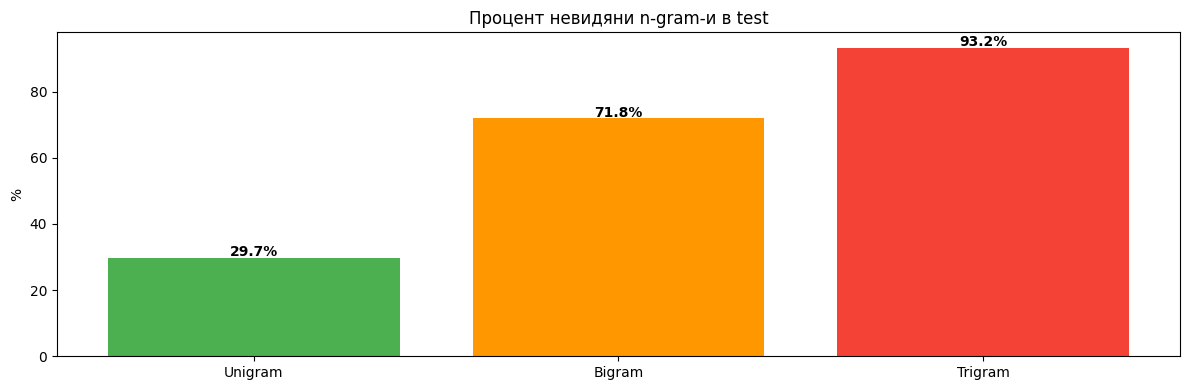

In [29]:
# Визуализация: невидяни n-gram-и
plt.bar(labels, pcts, color=["#4CAF50", "#FF9800", "#F44336"])
plt.title("Процент невидяни n-gram-и в test")
plt.ylabel("%")
for i, pct in enumerate(pcts):
    plt.text(i, pct + 0.5, f"{pct:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [31]:
# Извод: колкото по-дълъг е n-gram-ът, толкова повече комбинации
# в тестовите данни не са видяни при обучението.
# Това е основното ограничение на n-gram моделите — data sparsity.
print("Възможни комбинации:")
vocab = len(set(words))
print(f"  Unigram: {vocab:,}")
print(f"  Bigram:  {vocab:,}² = {vocab**2:,}")
print(f"  Trigram: {vocab:,}³ = {vocab**3:,}")
print(f"\nРеално наблюдавани (train):")
print(f"  Unigram: {len(train_unigrams):,}")
print(f"  Bigram:  {len(train_bigrams):,}")
print(f"  Trigram: {len(train_trigrams):,}")

Възможни комбинации:
  Unigram: 65,783
  Bigram:  65,783² = 4,327,403,089
  Trigram: 65,783³ = 284,669,557,403,687

Реално наблюдавани (train):
  Unigram: 58,633
  Bigram:  336,105
  Trigram: 491,986
